In [1]:
import os
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import pingouin as pg

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))


import nvitk as nv
from nvitk import db

repo, xnat_config = db.get_repo_from_settings(return_xnat_config=True)

Using local root: ~/nvitk/dataset/nvitk-dataset


In [2]:
aux = repo.image(modality='4dflow', variables=['flow_mean'], wide=False)
aux = aux[(aux['variable_id' ] == 'flow_mean') & (aux['value_num'].notna())]

_STATSMODELS_BASE_DIR = Path('/home/imarcoss/NetVolumes/Tierra/LAB_VF-ICH/LAB/MCC LAB/_IgnacioMarcos/LabVF/PESA-Brain/DB/nvitk-statmodels/')

_SUBJECTS = pd.unique(aux.subject_uid)
_CLINICAL_VARS = ['age_at_mri', 'apoe_group', 'apoe', 'bmi', 'pp', 'map', 'hematocrit', 'pedframi10', 'pedframi30', 'sex', 'score2', 'tacsctot_group']
_PLAQUE_VARS = ['total_carotid_plaque_vol', 'total_femoral_plaque_vol', 'total_plaque_vol', 'right_carotid_plaque_vol', 'left_carotid_plaque_vol']
_COGNITIVE_VARS = ['z_compo_processingspeed', 'z_compo_globalfull', 'z_compo_epismemory', 'z_compo_attworkmemospeed']
_FLOW_VARS = ['flow_mean', 'pi']
_ASL_VARS = ['mean_cbf', 'att_mean']

TERRITORY_FLOW_REGIONS: dict[str, tuple[str, ...]] = {
    "ACA": ( "left_aca", "right_aca"),
    "MCA": ("left_mca", "right_mca"),
    "PCA": ("left_pca", "right_pca"),
    "Basilar": ("basilar",),
    # "ICA-WS": ("left_ica", "right_ica"),
    # "ICA-WB": ("left_ica", "right_ica"),
    # "Venous-WB": ("sagital_sinus", "straight_sinus", "left_transverse", "right_transverse"),
}

TERRITORY_ASL_V8_REGIONS: dict[str, tuple[str, ...]] = {
    "ACA": (
        "left_aca_8",
        "right_aca_8",
    ),
    "MCA": (
        "left_mca_8",
        "right_mca_8",
    ),
    "PCA": (
        "left_pca_8",
        "right_pca_8",
    ),
    "Basilar": (
        "left_basilar_8",
        "right_basilar_8",
    ),
    # "ICA-WS": ("watershed_0", "watershed_8"),
    # "ICA-WB": ("ctx_whole_brain",),
    # "Venous-WB": ("ctx_whole_brain",),
}

In [3]:
clinical  = repo.clinical(variables=_CLINICAL_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
plaque    = repo.clinical(variables=_PLAQUE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
cognitive = repo.cognitive(variables=_COGNITIVE_VARS, filters={'subject_uid': {'$in': _SUBJECTS}})
clinical   = repo.join([clinical, plaque, cognitive])

flow      = repo.image(modality='4dflow', variables=_FLOW_VARS, filters={'subject_uid': {'$in': _SUBJECTS}}, pipeline='v1')
asl       = repo.image(modality='asl', variables=_ASL_VARS, atlas='vascular-8', filters={'subject_uid': {'$in': _SUBJECTS}})
asl_wb    = repo.image(
    modality='asl', variables=_ASL_VARS, atlas='desikan', 
    regions=['ctx-whole-brain'],
    filters={'subject_uid': {'$in': _SUBJECTS}}
    )
image_df  = repo.join([flow, asl, asl_wb])

territory_df = nv.stats.melt_imaging_territories(
    image_df, id_cols=['subject_uid'], 
    flow_vars=_FLOW_VARS, asl_vars=_ASL_VARS, 
    territory_flow_regions=TERRITORY_FLOW_REGIONS,
    territory_asl_v8_regions=TERRITORY_ASL_V8_REGIONS,
    include_frame_index=False
)

_COVAR_FOR_MODEL = [
    "tacsctot_group",
    "age_at_mri",
    "sex",
    "hematocrit",
    "score2",
    "pp",
    "map"
]
_cov = [c for c in _COVAR_FOR_MODEL if c in clinical.columns]

# Explicit flow vs ASL region lists per analysis territory (same ASL region can
# pair with different flow groups, e.g. ctx-whole-brain for ICA-WB and Venous-WB).
TERRITORY_DEFINITIONS = {
    name: {"flow": TERRITORY_FLOW_REGIONS[name], "asl": TERRITORY_ASL_V8_REGIONS[name]}
    for name in TERRITORY_FLOW_REGIONS
}
analysis_df = nv.stats.build_analysis_df_from_territory_definitions(
    image_df,
    clinical,
    TERRITORY_DEFINITIONS,
    flow_vars=_FLOW_VARS,
    asl_vars=_ASL_VARS,
    covariate_cols=_cov,
)

analysis_df = analysis_df.dropna().reset_index(drop=True)
analysis_df["age_c"] = analysis_df["age_at_mri"] - float(analysis_df["age_at_mri"].mean())
analysis_df = analysis_df.drop(columns=['age_at_mri'])
analysis_df['territory'] = pd.Categorical(analysis_df['territory'], categories=list(TERRITORY_ASL_V8_REGIONS.keys()), ordered=True)
analysis_df['tacsctot_group'] = pd.Categorical(analysis_df['tacsctot_group'], categories=['g0', 'g1', 'g2', 'g3'], ordered=True)
analysis_df['mean_cbf'] = analysis_df['mean_cbf'].astype(np.float32)
analysis_df['hematocrit'] = analysis_df['hematocrit'].astype(np.float32)
analysis_df['score2'] = analysis_df['score2'].astype(np.float32)
analysis_df['pp'] = analysis_df['pp'].astype(np.float32)
analysis_df['age_c'] = analysis_df['age_c'].astype(np.float32)
analysis_df

,subject_uid,territory,flow_mean,pi,mean_cbf,att_mean,tacsctot_group,sex,hematocrit,score2,pp,map,age_c
0,PESA1006009,ACA,146.617585,0.722523,58.483761,1.280129,g0,1,47.0,4.625464,49.0,91.333333,5.082217
1,PESA10061584,ACA,58.467905,0.837771,40.072781,1.305152,g2,1,48.0,5.979170,53.0,102.666667,6.482217
2,PESA10067929,ACA,113.204603,0.724601,59.831661,1.226889,g0,1,42.0,7.063850,62.0,106.666667,6.752217
3,PESA10086976,ACA,63.311970,0.608145,57.035610,1.221132,g0,0,45.0,1.596673,32.0,89.666667,-4.597783
4,PESA10112400,ACA,132.874938,0.613769,56.868347,1.232920,g0,1,48.0,3.986971,58.0,108.333333,-4.047783
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,PESA9897316,Basilar,178.221377,0.674136,45.512760,1.109104,g1,1,52.0,4.760891,39.0,81.0,-2.437783
1340,PESA9928801,Basilar,87.832792,0.567656,57.890354,1.080371,g0,0,45.0,2.783649,31.0,83.333333,4.342217
1341,PESA9935104,Basilar,245.827435,0.719752,39.562092,1.066424,g0,0,45.0,2.478144,46.0,91.333333,2.802217
1342,PESA9947716,Basilar,309.712580,0.857074,50.096241,1.116286,g1,1,42.0,3.722327,43.0,85.333333,1.342217


In [4]:

# Match the same columns used in the notebook
model_cols = [
    "subject_uid", "territory",
    "pi", "pp", "att_mean",
    "age_c", "sex", "hematocrit", "score2"
]

df = analysis_df[model_cols].dropna().copy()

# IMPORTANT:
# pingouin mediation_analysis is not mixed-effects.
# To avoid pseudo-replication across territories, aggregate to subject-level first.
df_subj = (
    df.groupby("subject_uid", as_index=False)
      .agg({
          "pi": "mean",
          "pp": "mean",
          "att_mean": "mean",
          "age_c": "mean",
          "sex": "first",
          "hematocrit": "mean",
          "score2": "mean",
      })
)

# Mediation: X=pi, M=pp, Y=att_mean, with same covariates as your model
med = pg.mediation_analysis(
    data=df_subj,
    x="pi",
    m="pp",
    y="att_mean",
    covar=["age_c", "sex", "hematocrit", "score2"],
    n_boot=500,
    alpha=0.05,
    seed=42,
    return_dist=True,  # returns bootstrap distribution of indirect effect
)

# pingouin returns (stats_df, boot_dist) when return_dist=True
med_stats, boot_dist = med

print(med_stats)
print("\nIndirect effect row:")
print(med_stats.loc[med_stats["path"] == "Indirect"])

       path       coef        se          pval      CI2.5     CI97.5  sig
0    pp ~ X  24.403188  4.044036  4.262361e-09  16.448023  32.358353  Yes
1    Y ~ pp  -0.000785  0.000368  3.370013e-02  -0.001509  -0.000061  Yes
2     Total   0.061643  0.028563  3.163311e-02   0.005456   0.117829  Yes
3    Direct   0.089656  0.029733  2.765108e-03   0.031167   0.148146  Yes
4  Indirect  -0.028014  0.012051  8.000000e-03  -0.055347  -0.009040  Yes

Indirect effect row:
       path      coef        se   pval     CI2.5   CI97.5  sig
4  Indirect -0.028014  0.012051  0.008 -0.055347 -0.00904  Yes


One mediation per territory

In [6]:
results_by_territory = {}

for terr, dft in df.groupby("territory"):
    # still aggregate repeated rows within subject if needed
    dft_subj = (
        dft.groupby("subject_uid", as_index=False)
           .agg({
               "pi": "mean",
               "pp": "mean",
               "att_mean": "mean",
               "age_c": "mean",
               "sex": "first",
               "hematocrit": "mean",
               "score2": "mean",
           })
    )

    res = pg.mediation_analysis(
        data=dft_subj,
        x="pi",
        m="pp",
        y="att_mean",
        covar=["age_c", "sex", "hematocrit", "score2"],
        n_boot=3000,
        seed=42,
    )
    results_by_territory[terr] = res

for terr, res in results_by_territory.items():
    print(f"\n=== {terr} ===")
    print(res.loc[res["path"] == "Indirect"]) # , ["coef", "se", "pval", "CI[2.5%]", "CI[97.5%]"]


=== ACA ===
       path     coef        se  pval     CI2.5    CI97.5  sig
4  Indirect -0.00786  0.004233  0.03 -0.018437 -0.001419  Yes

=== MCA ===
       path     coef        se   pval    CI2.5    CI97.5  sig
4  Indirect -0.01099  0.005771  0.016 -0.02577 -0.002189  Yes

=== PCA ===
       path      coef        se      pval     CI2.5   CI97.5 sig
4  Indirect -0.011748  0.007974  0.082667 -0.033156  0.00002  No

=== Basilar ===
       path      coef        se      pval     CI2.5    CI97.5  sig
4  Indirect -0.036984  0.022521  0.047333 -0.097431 -0.003329  Yes


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

def plot_indirect_bootstrap(boot_dist, ci_low=None, ci_high=None, ax=None, bins=50):
    """
    Plot bootstrap distribution of indirect effect (a*b).
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    boot_dist = np.asarray(boot_dist)
    ax.hist(boot_dist, bins=bins, alpha=0.35, color="#4C72B0", density=True)

    # KDE overlay
    xs = np.linspace(np.min(boot_dist), np.max(boot_dist), 300)
    kde = gaussian_kde(boot_dist)
    ax.plot(xs, kde(xs), color="#1F4E79", lw=2, label="KDE")

    # Reference lines
    ax.axvline(0, color="black", ls="--", lw=1.5, label="0 (null)")
    if ci_low is None:
        ci_low = np.percentile(boot_dist, 2.5)
    if ci_high is None:
        ci_high = np.percentile(boot_dist, 97.5)

    ax.axvline(ci_low, color="#C44E52", ls="--", lw=2, label=f"CI low: {ci_low:.4f}")
    ax.axvline(ci_high, color="#55A868", ls="--", lw=2, label=f"CI high: {ci_high:.4f}")

    ax.set_title("Bootstrap Distribution of Indirect Effect (a*b)")
    ax.set_xlabel("Indirect effect")
    ax.set_ylabel("Density")
    ax.legend(frameon=True)
    return fig, ax

def plot_mediation_paths_forest(med_stats, ax=None):
    """
    Forest plot for mediation path coefficients and CIs from pingouin result table.
    Expects columns like: path, coef, CI[2.5%], CI[97.5%]
    """
    df = med_stats.copy()

    # Keep common paths if present, otherwise show all
    preferred_order = ["a", "b", "c", "c'", "Indirect", "Direct", "Total"]
    paths_present = [p for p in preferred_order if p in df["path"].values]
    if len(paths_present) == 0:
        paths_present = df["path"].tolist()

    df = df[df["path"].isin(paths_present)].copy()
    df["path"] = pd.Categorical(df["path"], categories=paths_present, ordered=True)
    df = df.sort_values("path")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = ax.figure

    y = np.arange(len(df))
    coef = df["coef"].values
    lo = df["CI2.5"].values
    hi = df["CI97.5"].values

    xerr = np.vstack([coef - lo, hi - coef])
    ax.errorbar(coef, y, xerr=xerr, fmt="o", color="#4C72B0", ecolor="#4C72B0", capsize=4)

    ax.axvline(0, color="black", lw=1.5, ls="--")
    ax.set_yticks(y)
    ax.set_yticklabels(df["path"])
    ax.set_xlabel("Effect size (coef with 95% CI)")
    ax.set_title("Mediation Path Estimates")
    return fig, ax

import statsmodels.api as sm

def _residualize(y, X):
    X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X, missing="drop").fit()
    return model.resid

def plot_partial_paths(df, x="pi", m="pp", y="att_mean",
                       covars=("age_c", "sex", "hematocrit", "score2"),
                       figsize=(12, 5)):
    """
    Visualize adjusted relationships:
      - a path: M ~ X + covars
      - b path: Y ~ M + X + covars  (show Y residualized against X+covars vs M residualized against X+covars)
    """
    d = df[[x, m, y, *covars]].dropna().copy()

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # a path partial plot: residual(M|covars) vs residual(X|covars)
    rx = _residualize(d[x], d[list(covars)])
    rm = _residualize(d[m], d[list(covars)])
    sns.regplot(x=rx, y=rm, ax=axes[0], scatter_kws={"alpha": 0.6}, line_kws={"color": "#C44E52"})
    axes[0].set_title("a path (adjusted): pi -> pp")
    axes[0].set_xlabel(f"{x} residualized on covariates")
    axes[0].set_ylabel(f"{m} residualized on covariates")

    # b path partial plot: residual(Y|X+covars) vs residual(M|X+covars)
    rmx = _residualize(d[m], d[[x, *covars]])
    ryx = _residualize(d[y], d[[x, *covars]])
    sns.regplot(x=rmx, y=ryx, ax=axes[1], scatter_kws={"alpha": 0.6}, line_kws={"color": "#55A868"})
    axes[1].set_title("b path (adjusted): pp -> att_mean | pi")
    axes[1].set_xlabel(f"{m} residualized on {x}+covariates")
    axes[1].set_ylabel(f"{y} residualized on {x}+covariates")

    plt.tight_layout()
    return fig, axes

def plot_indirect_by_territory(results_by_territory, ax=None):
    """
    results_by_territory: dict[territory] -> pingouin mediation result DataFrame
    """
    rows = []
    for terr, res in results_by_territory.items():
        r = res[res["path"] == "Indirect"].iloc[0]
        rows.append({
            "territory": terr,
            "coef": r["coef"],
            "lo": r["CI[2.5%]"],
            "hi": r["CI[97.5%]"],
            "pval": r.get("pval", np.nan),
        })
    out = pd.DataFrame(rows).sort_values("coef")

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(out))))
    else:
        fig = ax.figure

    y = np.arange(len(out))
    ax.errorbar(out["coef"], y,
                xerr=[out["coef"] - out["lo"], out["hi"] - out["coef"]],
                fmt="o", capsize=4, color="#4C72B0")
    ax.axvline(0, color="black", ls="--", lw=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(out["territory"])
    ax.set_xlabel("Indirect effect (a*b) with 95% CI")
    ax.set_title("Indirect Effects by Territory")
    return fig, ax, out

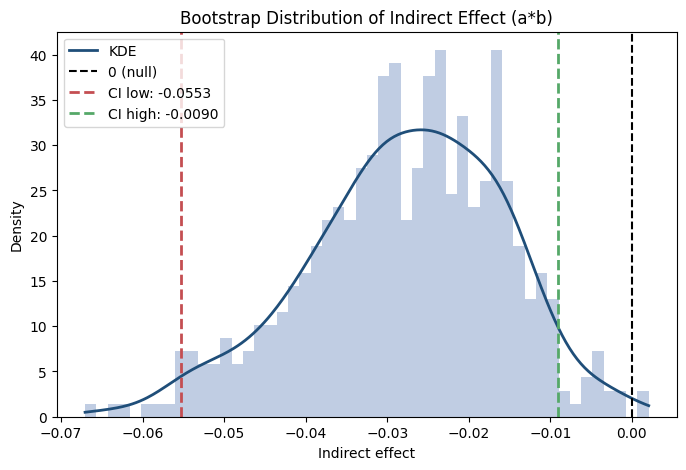

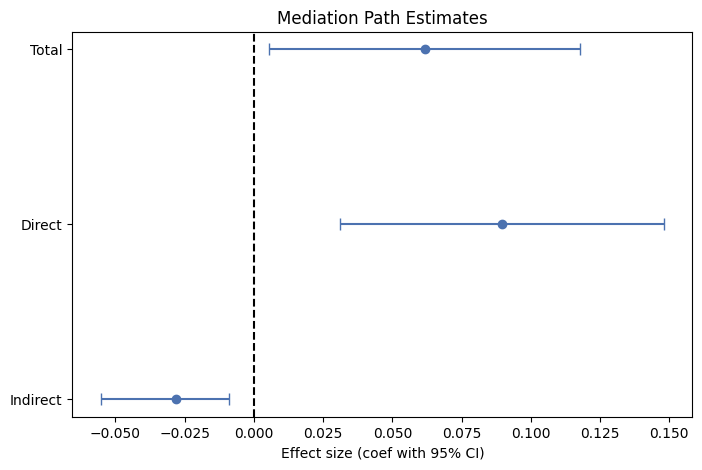

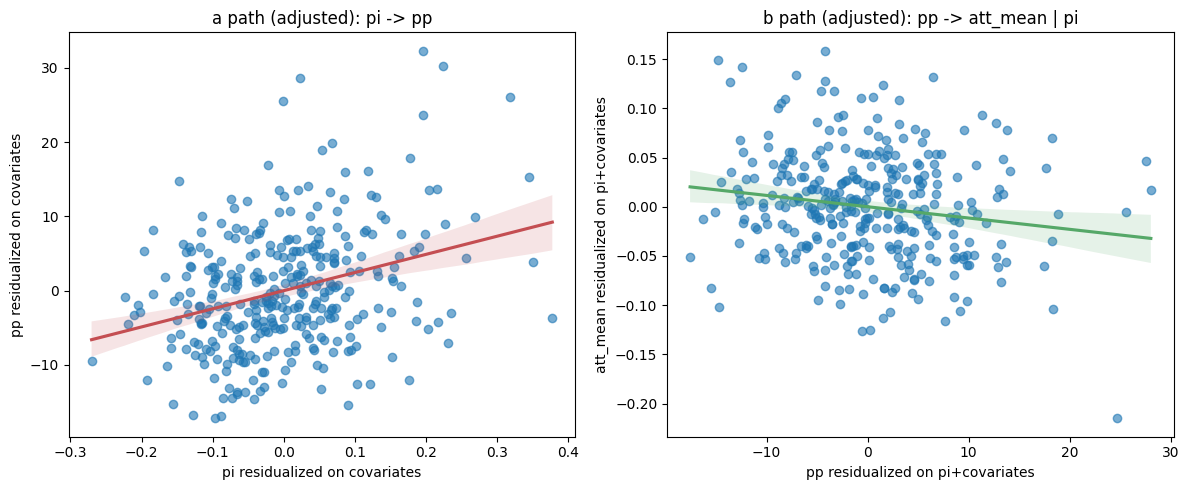

In [11]:
# 1) Distribution of indirect effect
ind_row = med_stats.loc[med_stats["path"] == "Indirect"].iloc[0]
plot_indirect_bootstrap(boot_dist, ci_low=ind_row["CI2.5"], ci_high=ind_row["CI97.5"])

# 2) Forest plot of all paths
plot_mediation_paths_forest(med_stats)

# 3) Adjusted path visualizations
plot_partial_paths(df_subj, x="pi", m="pp", y="att_mean",
                   covars=("age_c", "sex", "hematocrit", "score2"))
plt.show()